# Multi-Agent RL: Cooperative and Competitive Agents

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand multi-agent RL concepts
- Implement multi-agent environments
- Train cooperative agents
- Train competitive agents
- Compare multi-agent approaches

## 🔗 Prerequisites

- ✅ Understanding of single-agent RL
- ✅ Understanding of policies and value functions
- ✅ Python, NumPy knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Implementing multi-agent RL environments and training cooperative/competitive agents

---

## Introduction

**Multi-agent RL** involves multiple agents learning and interacting in the same environment, either cooperatively (shared goals) or competitively (conflicting goals).

## Lesson Brief

This lesson introduces environments where more than one agent is learning at the same time.

Students will see how cooperation and competition create new difficulties that do not exist in single-agent RL.

Why this matters: many real systems involve multiple decision-makers, not only one isolated learner.

This lesson helps students understand why multi-agent environments feel less stable.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


In [1]:
import numpy as np

print("✅ Libraries imported!")
print("\nMulti-Agent RL: Cooperative and Competitive Agents")
print("=" * 60)

print("\nMulti-Agent RL Types:")
print("  - Cooperative: Agents share rewards, work toward common goal")
print("  - Competitive: Agents have conflicting goals (zero-sum)")
print("  - Mixed: Combination of cooperation and competition")

print("\nKey Challenges:")
print("  - Non-stationary environment (other agents learn)")
print("  - Credit assignment (who gets credit)")
print("  - Coordination (communicating/coordinating actions)")
print("  - Scalability (many agents)")

print("\n✅ Multi-agent RL concepts understood!")

✅ Libraries imported!

Multi-Agent RL: Cooperative and Competitive Agents

Multi-Agent RL Types:
  - Cooperative: Agents share rewards, work toward common goal
  - Competitive: Agents have conflicting goals (zero-sum)
  - Mixed: Combination of cooperation and competition

Key Challenges:
  - Non-stationary environment (other agents learn)
  - Credit assignment (who gets credit)
  - Coordination (communicating/coordinating actions)
  - Scalability (many agents)

✅ Multi-agent RL concepts understood!


## 🌍 Real-World Worked Example — Competitive Multi-Agent with Independent Q-Learning

**Industry context:**
- Waymo simulates thousands of autonomous vehicles (agents) sharing the same road
- Google DeepMind's AlphaStar has 10 agents competing simultaneously in StarCraft II

We simulate a simple **2-agent grid competition** where two agents learn to navigate to goals while avoiding each other.

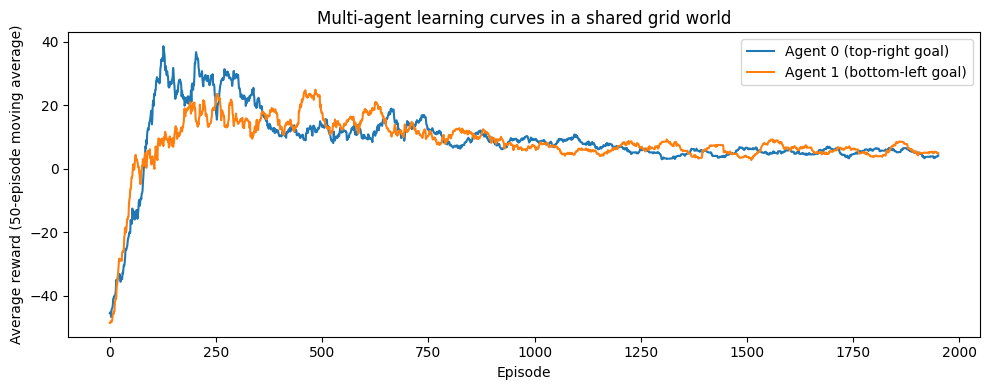


Final average rewards -> Agent 0: 4.6, Agent 1: 4.7

Teaching point:
Each agent learns while the other agent is also changing, which makes the
environment non-stationary from any single agent's perspective.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
GRID = 5
N_ACTIONS = 4
DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1)]


def state_to_idx(r, c):
    return r * GRID + c


def step_agent(pos, action):
    dr, dc = DELTAS[action]
    return (max(0, min(GRID - 1, pos[0] + dr)), max(0, min(GRID - 1, pos[1] + dc)))


GOALS = [(0, GRID - 1), (GRID - 1, 0)]
Q = [np.zeros((GRID * GRID, N_ACTIONS)) for _ in range(2)]
alpha = 0.1
gamma = 0.95
eps = 1.0
eps_decay = 0.998
rewards_hist = [[], []]

for ep in range(2000):
    pos = [(GRID - 1, 0), (0, GRID - 1)]
    ep_r = [0, 0]
    for _ in range(50):
        actions = []
        for i in range(2):
            s = state_to_idx(*pos[i])
            a = np.random.randint(N_ACTIONS) if np.random.rand() < eps else Q[i][s].argmax()
            actions.append(a)
        new_pos = [step_agent(pos[i], actions[i]) for i in range(2)]
        for i in range(2):
            s = state_to_idx(*pos[i])
            s2 = state_to_idx(*new_pos[i])
            r = 10 if new_pos[i] == GOALS[i] else -1
            r -= 5 if new_pos[0] == new_pos[1] else 0
            Q[i][s, actions[i]] += alpha * (r + gamma * Q[i][s2].max() - Q[i][s, actions[i]])
            ep_r[i] += r
        pos = new_pos
        if pos[0] == GOALS[0] and pos[1] == GOALS[1]:
            break
    for i in range(2):
        rewards_hist[i].append(ep_r[i])
    eps = max(eps * eps_decay, 0.05)

ma0 = np.convolve(rewards_hist[0], np.ones(50) / 50, "valid")
ma1 = np.convolve(rewards_hist[1], np.ones(50) / 50, "valid")
plt.figure(figsize=(10, 4))
plt.plot(ma0, label="Agent 0 (top-right goal)")
plt.plot(ma1, label="Agent 1 (bottom-left goal)")
plt.title("Multi-agent learning curves in a shared grid world")
plt.xlabel("Episode")
plt.ylabel("Average reward (50-episode moving average)")
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"\nFinal average rewards -> Agent 0: {np.mean(rewards_hist[0][-100:]):.1f}, "
    f"Agent 1: {np.mean(rewards_hist[1][-100:]):.1f}"
)
print("\nTeaching point:")
print("Each agent learns while the other agent is also changing, which makes the")
print("environment non-stationary from any single agent's perspective.")

## 📚 References & Further Reading

**Papers:**
- Lowe et al. (2017) — [Multi-Agent Actor-Critic (MADDPG)](https://arxiv.org/abs/1706.02275)
- OpenAI (2019) — [OpenAI Five: Dota2 with Multi-Agent RL](https://openai.com/five/)
- Vinyals et al. (2019) — [AlphaStar: StarCraft II](https://www.nature.com/articles/s41586-019-1724-z)

**State-of-the-Art:**
- Waymo uses multi-agent simulation (many cars interacting) to train autonomous vehicles
- Uber's route optimisation treats every driver as an agent in a shared environment

## 📝 Summary

You explored **Multi-Agent Reinforcement Learning (MARL)** where multiple agents interact in shared environments. Independent Q-Learning is simple but can be unstable. Real applications: autonomous vehicles at intersections, trading algorithms, and multiplayer game AI.

## Closing Takeaway

**Teaching takeaway:** Multi-agent RL becomes harder because each agent changes the environment seen by the others, creating non-stationarity.

**If students remember one idea:** When many learners act together, the world changes not only because of the environment but because the other learners keep adapting too.

**Quick check before moving on:**
- Can you explain why training becomes less stable when other agents are also learning?
- Can you describe the difference between cooperative and competitive multi-agent settings?

**Bridge to the next step:** Next, students will see how hierarchical structure can simplify long or complex tasks even in single-agent settings.
